In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

##load dataset

data = pd.read_csv("winequality-red.csv")
print(data.head())
print("dataset size = ",data.shape)
print("columns =",data.columns)
print("missing values =",data.isnull().sum())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [4]:
##faeature and target ##
x = data.drop("quality",axis=1) #feature 11 col
y = data["quality"] #target

In [5]:
##standardize the feature 
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [6]:
###apply pca 
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

print("variance ratio =",pca.explained_variance_ratio_)
print("total variance explained =",sum(pca.explained_variance_ratio_))

variance ratio = [0.28173931 0.1750827 ]
total variance explained = 0.4568220118429404


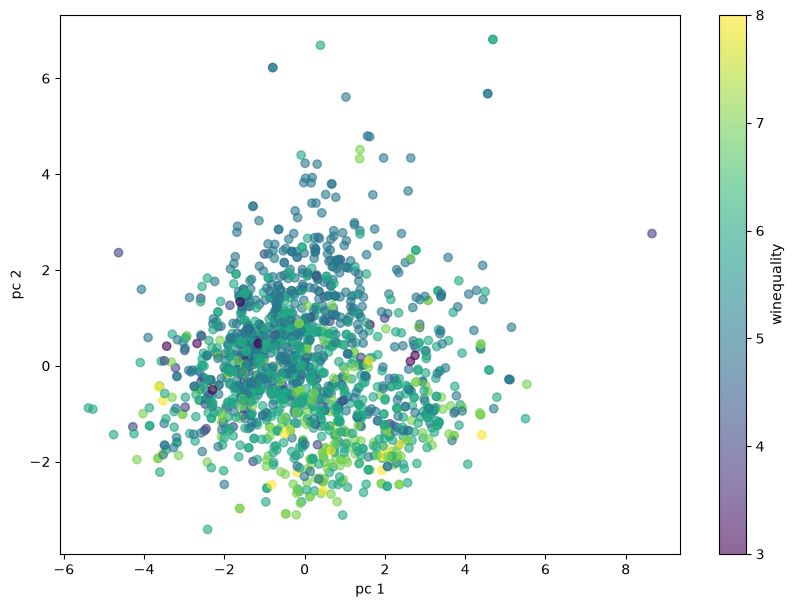

In [7]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(x_pca[:,0],x_pca[:,1],c=y,cmap="viridis",alpha=0.6)
plt.colorbar(scatter,label="winequality")
plt.xlabel("pc 1")
plt.ylabel("pc 2")
plt.title=("pca of wine quality")
plt.show()

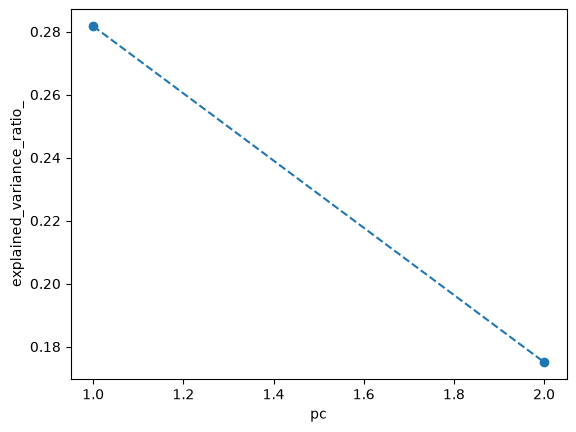

In [9]:
###SCREE PLOT --> VARIANCE PER COMPONENT
plt.plot(range(1,3),pca.explained_variance_ratio_,marker="o",linestyle="--")
plt.xlabel("pc")
plt.ylabel("explained_variance_ratio_")
plt.title=("scree plot")
plt.show()

In [14]:
##train classification after pca 
x_train,x_test,y_train,y_test = train_test_split(x_pca,y,test_size=0.2,random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print("accuracy =",accuracy)


#compare with original feature ##
x_train_o,x_test_o,y_train_o,y_test_o = train_test_split(x_scaled,y,test_size=0.2,random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(x_train_o,y_train)
y_pred_o = clf.predict(x_test_o)
accuracy_o = accuracy_score(y_test_o,y_pred_o)
print(" original accuracy =",accuracy_o)


accuracy = 0.5375
 original accuracy = 0.65
